# Context Overlap Mechanism

> Demonstrate that interference requires context overlap, not mere competitor existence.

The selective interference paradigm encodes film items, then break items
(modeling a retention interval), a reminder that reinstates film context,
interference items, and filler items before free recall.

This notebook tests the core mechanism claim: competitors interfere with
film recall via context overlap, not mere existence.

**Design.** Two break items at high drift move context far from the film
region. Then two conditions diverge on whether the reminder reinstates
film context before interference encoding:

- **Context overlap** (reminder ON): The reminder reinstates film context.
  Competitors are encoded starting from film-adjacent context.
- **Distant context** (reminder OFF): No reinstatement. Competitors are
  encoded starting from break-end context, far from film.

Both conditions are swept over interference drift scale (0.2–1.6).
Low drift keeps competitors near their starting position; high drift
pushes them away rapidly.

The prediction: at low drift, the overlap condition should show more
interference (competitors trapped in film context) while the distant
condition should show less (competitors trapped in break-end context).
The gap should narrow at high drift, where competitors spread out
regardless of starting position.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from jax import random

from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.plotting import init_plot, set_plot_labels
from jaxcmr.selective_interference import (
    Paradigm,
    film_recalled_stats,
    load_or_fit_params,
    make_factory,
    prepare_sweep,
    run_sweep,
)

warnings.filterwarnings("ignore")

In [2]:
# --- paradigm geometry ---
N_FILM = 16
N_BREAK = 2
N_INTERFERENCE = 16
N_FILLER = 16
BREAK_DRIFT_SCALE = 3.0
EXPERIMENT_COUNT = 100

# --- reminder conditions ---
OVERLAP_SCALES = {
    "reminder_start_drift_scale": 4.0,
    "reminder_drift_scale": 1.0,
}
DISTANT_SCALES = {
    "reminder_start_drift_scale": 0.0,
    "reminder_drift_scale": 0.0,
}

# --- drift scale sweep ---
DRIFT_VALUES = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]

# --- fitting ---
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
TRIAL_QUERY = "data['listtype'] == -1"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 3
RUN_TAG = "fixed_term_best_of_3"
REDO_FITS = False
PARAM_SCALES = {"stop_probability_scale": 0.57}
FIT_DIR = "projects/selective_interference/simulations/fits"

# --- output ---
FIGURE_DIR = "projects/selective_interference/simulations/figures"
FIGURE_STR = "context_overlap"

In [3]:
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    experiment_count=EXPERIMENT_COUNT,
)

project_root = Path(find_project_root())
fit_path = project_root / FIT_DIR / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

data = load_data(str(project_root / DATA_PATH))
trial_mask = generate_trial_mask(data, TRIAL_QUERY)
factory = make_factory()
rng = random.PRNGKey(SEED)

params, n_subjects = load_or_fit_params(
    fit_path,
    param_scales=PARAM_SCALES,
    data=data,
    trial_mask=trial_mask,
    model_factory=factory,
    redo_fits=REDO_FITS,
    best_of=BEST_OF,
)

prep = prepare_sweep(
    params, paradigm, factory,
    cache_after="break",
    break_drift_scale=BREAK_DRIFT_SCALE,
)
print(f"{n_subjects} subjects, cache_after=break, break_drift_scale={BREAK_DRIFT_SCALE}")

Loaded fits from /Users/jordangunn/jaxcmr/projects/selective_interference/simulations/fits/HealeyKahana2014_WeirdCMRPosStop_fixed_term_best_of_3.json
  Scaled stop_probability_scale by 0.57


126 subjects, cache_after=break, break_drift_scale=3.0


In [4]:
reminder_conditions = {
    "Context overlap": OVERLAP_SCALES,
    "Distant context": DISTANT_SCALES,
}

drift_arr = np.array(DRIFT_VALUES)

dose_response = {}
for label, rem_scales in reminder_conditions.items():
    rng = random.PRNGKey(SEED)
    recalls_4d, rng = run_sweep(
        prep, rng,
        interference_drift_scale=drift_arr,
        **rem_scales,
    )
    means, ci_lo, ci_hi = [], [], []
    for i in range(recalls_4d.shape[0]):
        recalls = recalls_4d[i].reshape(-1, recalls_4d.shape[-1])
        mu, lo, hi = film_recalled_stats(recalls, paradigm, n_subjects)
        means.append(mu)
        ci_lo.append(lo)
        ci_hi.append(hi)
    dose_response[label] = (np.array(means), np.array(ci_lo), np.array(ci_hi))
    print(f"{label}: drift=0.2 → {means[0]:.2f}, drift=1.6 → {means[-1]:.2f}, "
          f"Δ = {means[0] - means[-1]:.2f}")

Context overlap: drift=0.2 → 3.48, drift=1.6 → 3.93, Δ = -0.45


Distant context: drift=0.2 → 3.25, drift=1.6 → 3.93, Δ = -0.67


In [5]:
# Within-condition interference effects:
# baseline = recall at max drift (competitors most distant from start),
# effect = baseline - recall at each drift value.
effects = {}
for label, (means, ci_lo, ci_hi) in dose_response.items():
    baseline = means[-1]  # highest drift = least overlap
    effects[label] = baseline - means  # positive = interference

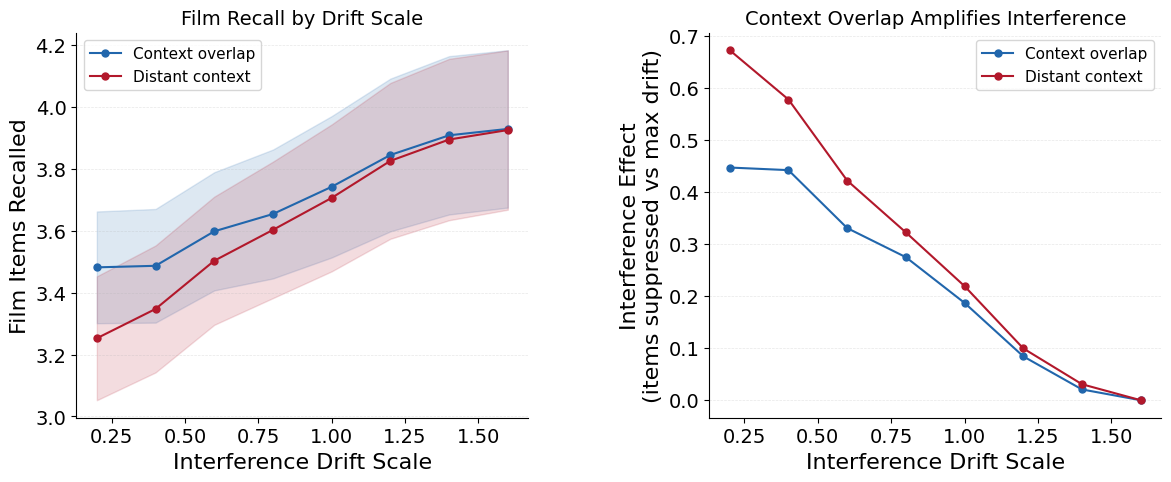

In [6]:
colors = {"Context overlap": "#2166ac", "Distant context": "#b2182b"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"wspace": 0.4})

# Left: Film recall vs interference drift scale (raw dose-response)
ax = init_plot(axes[0])
for label, (means, ci_lo, ci_hi) in dose_response.items():
    c = colors[label]
    ax.fill_between(drift_arr, ci_lo, ci_hi, alpha=0.15, color=c)
    ax.plot(drift_arr, means, "o-", color=c, label=label, linewidth=1.5, markersize=5)
set_plot_labels(ax, "Interference Drift Scale", "Film Items Recalled")
ax.set_title("Film Recall by Drift Scale", fontsize=14)
ax.legend(fontsize=11)

# Right: Within-condition interference effect (max-drift baseline)
ax = init_plot(axes[1])
for label, effect in effects.items():
    c = colors[label]
    ax.plot(drift_arr, effect, "o-", color=c, label=label, linewidth=1.5, markersize=5)
overlap_eff = effects["Context overlap"]
distant_eff = effects["Distant context"]
ax.fill_between(drift_arr, distant_eff, overlap_eff,
                where=(overlap_eff > distant_eff), alpha=0.15, color="#666666")
set_plot_labels(ax, "Interference Drift Scale", "Interference Effect\n(items suppressed vs max drift)")
ax.set_title("Context Overlap Amplifies Interference", fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()

if FIGURE_DIR and FIGURE_STR:
    fig_dir = str(project_root / FIGURE_DIR)
    os.makedirs(fig_dir, exist_ok=True)
    base = os.path.join(fig_dir, FIGURE_STR)
    plt.savefig(f"{base}.png", bbox_inches="tight", dpi=600)
    plt.savefig(f"{base}.svg", bbox_inches="tight")

plt.show()